# HW 8

### Minh Truong
### 141225

Perform the following activities in Python:    

- Get the dataset - pick any one of the datasets from the Datasets folder.
- Load the .csv file into a data frame in Python.
- Import necessary libraries.
- Describe the data, provide information on the dataset.
- Preprocess data if needed.
- Decide what is a good split and split the data using metrics like Gini Index, Entropy and Information Gain
- Train the decision tree
- Make Predictions
- Evaluate Model Accuracy
- Visualize the Decision Tree
- Provide conclusions based on the analysis 

# Decision Tree Classification
**Dataset:** Bank Personal Loan Modelling
**Target:** Personal Loan (0 = Rejected, 1 = Accepted)
**Size:** 5,000 customers, 14 features

## Import necessary libraries.

In [2]:
import pandas as pd                                     
import numpy as np                                       
import matplotlib.pyplot as plt                          
import seaborn as sns                                   
from sklearn.tree import DecisionTreeClassifier, plot_tree   
from sklearn.model_selection import train_test_split     
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

## Get the dataset - pick any one of the datasets from the Datasets folder.

Dataset: Bank Personal Loan Modelling

## Load the .csv file into a data frame in Python.

In [3]:
# Load dataset
df = pd.read_csv('/Users/mtruong/python-projects/Bank_Personal_Loan_Modelling (1).csv')
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


## Describe the data, provide information on the dataset.

In [4]:
# Summary statistics
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [5]:
# Check for missing values
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [6]:
# Class distribution: Personal Loan - Accepted vs. Rejected
df['Personal Loan'].value_counts()

Personal Loan
0    4520
1     480
Name: count, dtype: int64

## Preprocess data if needed.
- Drop ID and ZIP Code because they are not predictive features
- Define features and target
- Split 80/20

In [7]:
# Drop the columns that are not predictive features
df.drop(columns=['ID', 'ZIP Code'], inplace=True)

# Define features and target
X = df.drop(columns=['Personal Loan'])
y = df['Personal Loan']

# Split into 80% train, 20% test, and stratify to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

## Decide what is a good split and split the data using metrics like Gini Index, Entropy and Information Gain

In [8]:
# Compare Gini Index vs Entropy (Information Gain) to determine best split criterion
for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    model.fit(X_train, y_train)
    print(f"Criterion: {criterion:<10} Accuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

Criterion: gini       Accuracy: 0.9820
Criterion: entropy    Accuracy: 0.9920


## Train the decision tree

In [9]:
# Train final model using best criterion
dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dt.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Make Predictions

In [10]:
# Predict on the test set
y_pred = dt.predict(X_test)

## Evaluate Model Accuracy

In [11]:
# Overall accuracy
accuracy_score(y_test, y_pred)

0.991

In [12]:
# Precision, recall, and F1-score per class
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Accepted']))

              precision    recall  f1-score   support

    Rejected       0.99      1.00      1.00       904
    Accepted       0.96      0.95      0.95        96

    accuracy                           0.99      1000
   macro avg       0.98      0.97      0.97      1000
weighted avg       0.99      0.99      0.99      1000



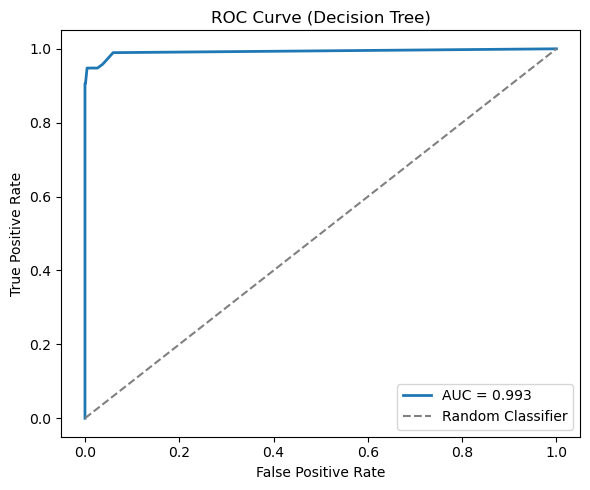

In [13]:
# Display ROC Curve because it measures the model's ability to separate classes
y_proba = dt.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Classifier')
plt.title('ROC Curve (Decision Tree)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

## Visualize the Decision Tree

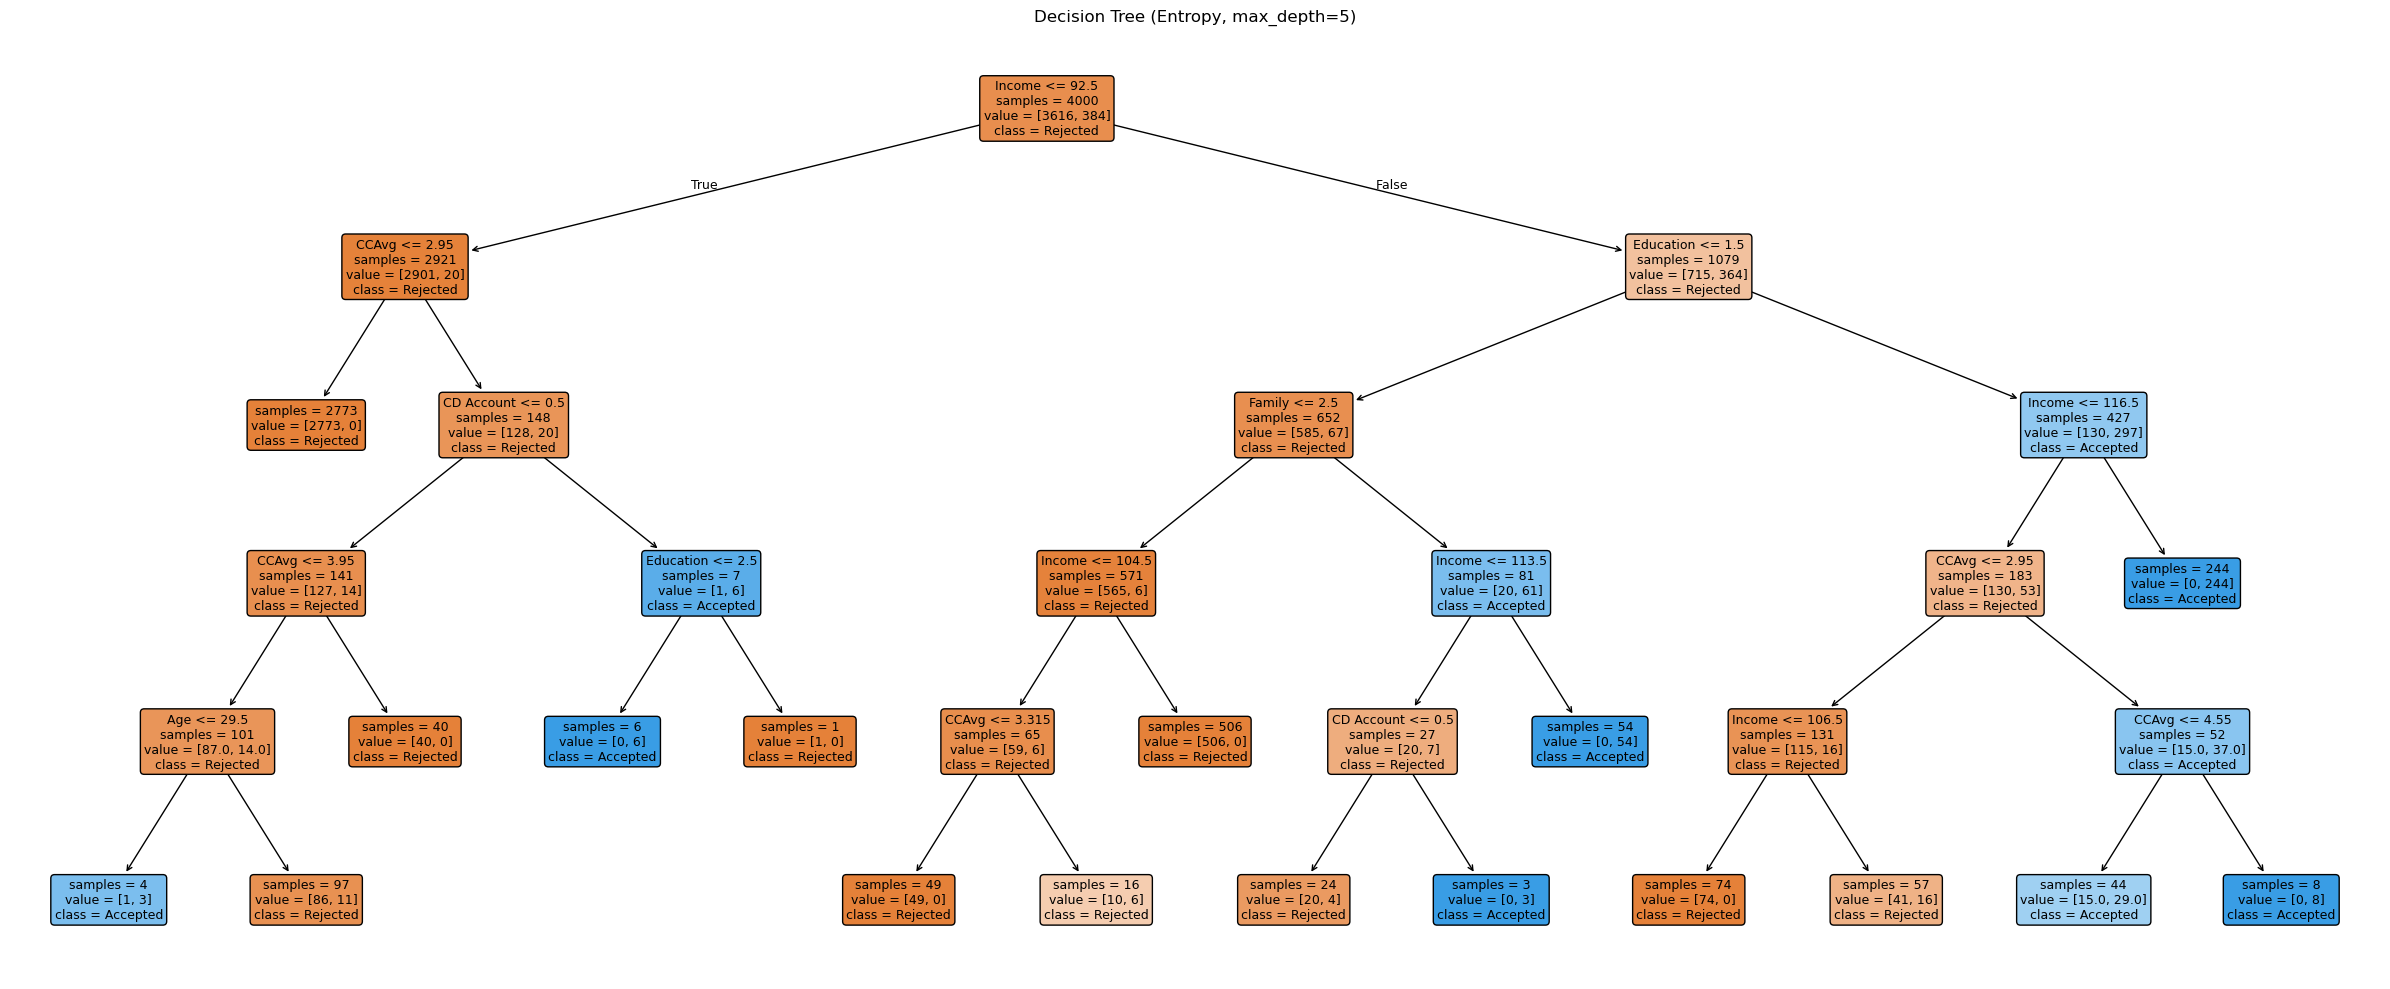

In [16]:
# Visualize the trained decision tree
plt.figure(figsize=(24, 10))
plot_tree(dt, feature_names=X.columns, class_names=['Rejected', 'Accepted'],
          filled=True, rounded=True, fontsize=9,
          impurity=False, proportion=False)
plt.title('Decision Tree')
plt.tight_layout()
plt.show()

## Provide conclusions based on the analysis

**Conclusion:**
The Decision Tree using Entropy (Information Gain) as the split criterion successfully classified personal loan acceptance with high accuracy, with Income, CCAvg, and Education appearing the most important splitting features.